<a href="https://colab.research.google.com/github/ualcsb547/tfg-gans-analisis-latente/blob/main/python_colab/generacion_imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fetch Codebase and Models

In [34]:
import os
os.chdir('/content')
CODE_DIR = 'interfacegan'
!git clone https://github.com/genforce/interfacegan.git $CODE_DIR
os.chdir(f'./{CODE_DIR}')
!wget https://www.dropbox.com/s/t74z87pk3cf8ny7/pggan_celebahq.pth?dl=1 -O models/pretrain/pggan_celebahq.pth --quiet
!wget https://www.dropbox.com/s/nmo2g3u0qt7x70m/stylegan_celebahq.pth?dl=1 -O models/pretrain/stylegan_celebahq.pth --quiet
!wget https://www.dropbox.com/s/qyv37eaobnow7fu/stylegan_ffhq.pth?dl=1 -O models/pretrain/stylegan_ffhq.pth --quiet

fatal: destination path 'interfacegan' already exists and is not an empty directory.


# Define Utility Functions

In [35]:
import os.path
import io
import IPython.display
import numpy as np
import cv2
import PIL.Image

import torch

from models.model_settings import MODEL_POOL
from models.pggan_generator import PGGANGenerator
from models.stylegan_generator import StyleGANGenerator
from utils.manipulator import linear_interpolate


def build_generator(model_name):
  """Builds the generator by model name."""
  gan_type = MODEL_POOL[model_name]['gan_type']
  if gan_type == 'pggan':
    generator = PGGANGenerator(model_name)
  elif gan_type == 'stylegan':
    generator = StyleGANGenerator(model_name)
  return generator


def sample_codes(generator, num, latent_space_type='Z', seed=0):
  """Samples latent codes randomly."""
  np.random.seed(seed)
  codes = generator.easy_sample(num)
  if generator.gan_type == 'stylegan' and latent_space_type == 'W':
    codes = torch.from_numpy(codes).type(torch.FloatTensor).to(generator.run_device)
    codes = generator.get_value(generator.model.mapping(codes))
  return codes


def imshow(images, col, viz_size=256):
  """Shows images in one figure."""
  num, height, width, channels = images.shape
  assert num % col == 0
  row = num // col

  fused_image = np.zeros((viz_size * row, viz_size * col, channels), dtype=np.uint8)

  for idx, image in enumerate(images):
    i, j = divmod(idx, col)
    y = i * viz_size
    x = j * viz_size
    if height != viz_size or width != viz_size:
      image = cv2.resize(image, (viz_size, viz_size))
    fused_image[y:y + viz_size, x:x + viz_size] = image

  fused_image = np.asarray(fused_image, dtype=np.uint8)
  data = io.BytesIO()
  PIL.Image.fromarray(fused_image).save(data, 'jpeg')
  im_data = data.getvalue()
  disp = IPython.display.display(IPython.display.Image(im_data))
  return disp

# Select a Model

In [36]:
#@title { display-mode: "form", run: "auto" }
model_name = "stylegan_ffhq" #@param ['pggan_celebahq','stylegan_celebahq', 'stylegan_ffhq']
latent_space_type = "W" #@param ['Z', 'W']

generator = build_generator(model_name)

ATTRS = ['age', 'eyeglasses', 'gender', 'pose', 'smile']
boundaries = {}
for i, attr_name in enumerate(ATTRS):
  boundary_name = f'{model_name}_{attr_name}'
  if generator.gan_type == 'stylegan' and latent_space_type == 'W':
    boundaries[attr_name] = np.load(f'boundaries/{boundary_name}_w_boundary.npy')
  else:
    boundaries[attr_name] = np.load(f'boundaries/{boundary_name}_boundary.npy')

# Sample latent codes

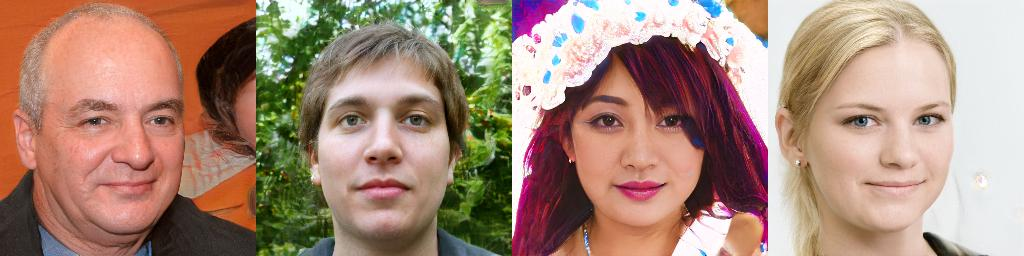

In [37]:
#@title { display-mode: "form", run: "auto" }

num_samples = 4 #@param {type:"slider", min:1, max:8, step:1}
noise_seed = 526 #@param {type:"slider", min:0, max:1000, step:1}

latent_codes = sample_codes(generator, num_samples, latent_space_type, noise_seed)
if generator.gan_type == 'stylegan' and latent_space_type == 'W':
  synthesis_kwargs = {'latent_space_type': 'W'}
else:
  synthesis_kwargs = {}

images = generator.easy_synthesize(latent_codes, **synthesis_kwargs)['image']
imshow(images, col=num_samples)

# Edit facial attributes

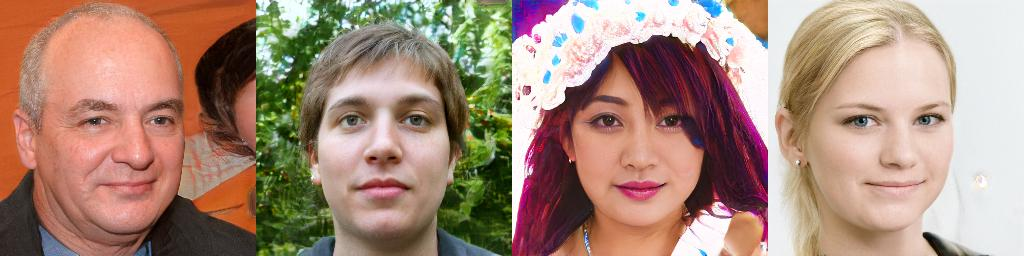

In [38]:
#@title { display-mode: "form", run: "auto" }

age = -0.2 #@param {type:"slider", min:-3.0, max:3.0, step:0.1}
eyeglasses = 0 #@param {type:"slider", min:-2.9, max:3.0, step:0.1}
gender = 0 #@param {type:"slider", min:-3.0, max:3.0, step:0.1}
pose = 0 #@param {type:"slider", min:-3.0, max:3.0, step:0.1}
smile = 0 #@param {type:"slider", min:-3.0, max:3.0, step:0.1}

new_codes = latent_codes.copy()
for i, attr_name in enumerate(ATTRS):
  new_codes += boundaries[attr_name] * eval(attr_name)

new_images = generator.easy_synthesize(new_codes, **synthesis_kwargs)['image']
imshow(new_images, col=num_samples)

***PCA (COMPONENTES PRINCIPALES)***


SOLO EJECUTAR EL SIGUIENTE CÓDIGO CUANDO SE QUIERAN EXPORTAR LOS DATOS DE LAS CARAS PARA HACER EN R LAS COMPONENTES PRINCIPALES

In [39]:
# SÓLO EJECUTAR CUANDO QUERAMOS HACERLO EN R, SI NO, NO HACE FALTA.
import pandas as pd

# 1. Usamos la función dada en el proyecto para generar 1000 caras aleatorias
numero_de_caras = 1000
print(f"Generando {numero_de_caras} vectores W")

vectores_w = sample_codes(generator, numero_de_caras, latent_space_type='W')

# 2. En StyleGAN, el espacio W a veces se expande a 18 capas (W+).
# Vamos a comprimirlo todo a la primera capa, puesto que las otras son copias.
if len(vectores_w.shape) == 3: # si tenemos algo tipo 1000x18x512
    vectores_w = vectores_w[:, 0, :] # aplastamos todo a la primera capa para no colapsar el ordenador

# 3. Lo metemos todo en una tabla y lo exportamos a CSV
df_vectores = pd.DataFrame(vectores_w)
df_vectores.to_csv('mis_vectores_stylegan.csv', index=False)
# index = False es para que no se haga una columna extra donde aparezca 1,2,3...

# 4. Para no pararnos a buscarlo, vamos a poner para descargarlo
from google.colab import files
files.download('mis_vectores_stylegan.csv')

Generando 1000 vectores W


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ahora, en R, sacamos las componentes principales guardadas como *direccion_pca1.csv*  y *direccion_pca2.csv*:



Cargando el vector PCA descubierto en R...
Generando imágenes...
Resultados:


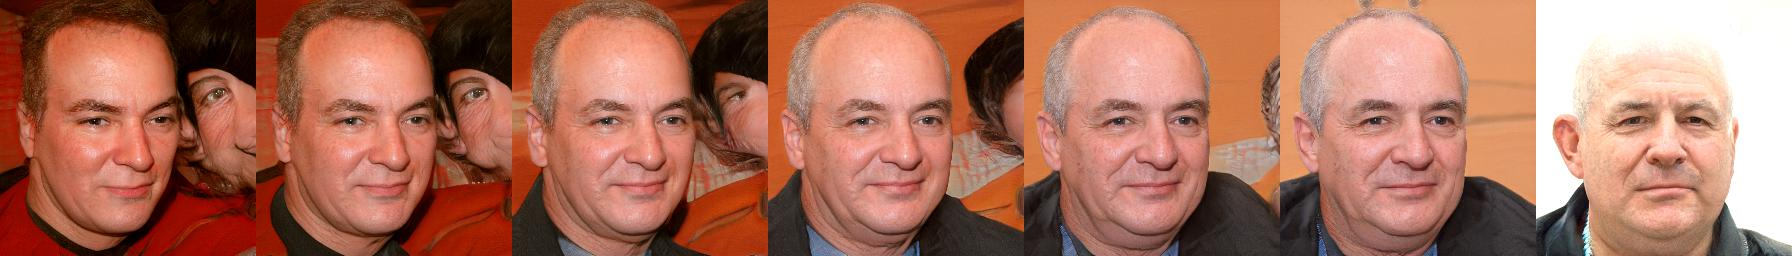

In [40]:
import pandas as pd
import numpy as np
import torch

print("Cargando el vector PCA descubierto en R...")

# 1. Cargamos el vector de R
df_pca = pd.read_csv('/content/direccion_pca1.csv')
# Para que esto no dé error, hay que meter previamente los archivos en la carpeta content

# Lo convertimos a formato NumPy y lo transponemos para que encaje bien (1, 512)
vector_pca = df_pca.values.T

# 2. Generamos una cara base aleatoria para probar
# Usamos la función anterior
#w_base = sample_codes(generator, 1, latent_space_type='W')
w_base = latent_codes[0:2]

# 3. Preparamos una lista vacía para guardar la evolución de la cara
imagenes_evolucion = []

# 4. Definimos las intensidades (alfa)
# Vamos a ir desde un extremo negativo hasta un extremo positivo
# 0.0 representa la cara base sin modificaciones
intensidades = [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 8.0]

print("Generando imágenes...")

for alfa in intensidades:
    # Sumamos a la cara base el vector PCA multiplicado por la intensidad
    w_modificado = w_base + (alfa * vector_pca)

    salida = generator.easy_synthesize(w_modificado, latent_space_type='W')
    imagen_final = salida['image'][0]

    # Guardamos la imagen generada en nuestra lista
    imagenes_evolucion.append(imagen_final)

print("Resultados:")

# 5. Visualización
# Convertimos la lista a un array tridimensional para la función
imagenes_array = np.array(imagenes_evolucion)

# Tantas columnas como intensidades hemos probado (7)
imshow(imagenes_array, col=len(intensidades))

Cargando el vector PCA descubierto en R...
Generando imágenes...
Resultados:


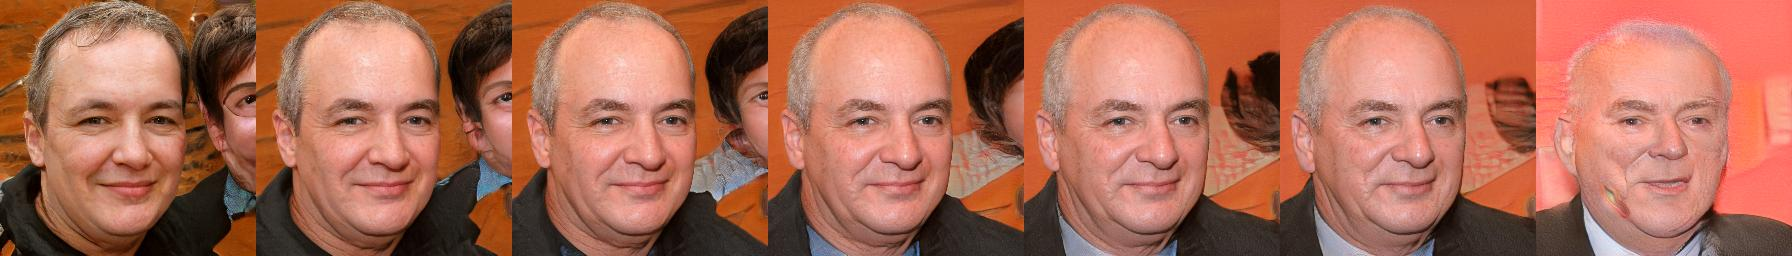

In [41]:
import pandas as pd
import numpy as np
import torch

print("Cargando el vector PCA descubierto en R...")

# 1. Cargamos el vector de R
df_pca = pd.read_csv('/content/direccion_pca2.csv')
# Para que esto no dé error, hay que meter previamente los archivos en la carpeta content

# Lo convertimos a formato NumPy y lo transponemos para que encaje bien (1, 512)
vector_pca = df_pca.values.T

# 2. Generamos una cara base aleatoria para probar
# Usamos la función anterior
w_base = latent_codes[0:2]

# 3. Preparamos una lista vacía para guardar la evolución de la cara
imagenes_evolucion = []

# 4. Definimos las intensidades (alfa)
# Vamos a ir desde un extremo negativo hasta un extremo positivo
# 0.0 representa la cara base sin modificaciones
intensidades = [-4.0, -2.0, -1.0, 0.0, 1.0, 2.0, 8.0]

print("Generando imágenes...")

for alfa in intensidades:
    # Sumamos a la cara base el vector PCA multiplicado por la intensidad
    w_modificado = w_base + (alfa * vector_pca)

    salida = generator.easy_synthesize(w_modificado, latent_space_type='W')
    imagen_final = salida['image'][0]

    # Guardamos la imagen generada en nuestra lista
    imagenes_evolucion.append(imagen_final)

print("Resultados:")

# 5. Visualización
# Convertimos la lista a un array tridimensional para la función
imagenes_array = np.array(imagenes_evolucion)

# Tantas columnas como intensidades hemos probado (7)
imshow(imagenes_array, col=len(intensidades))

Cargando el vector PCA descubierto en R...
Generando imágenes...
Resultados:


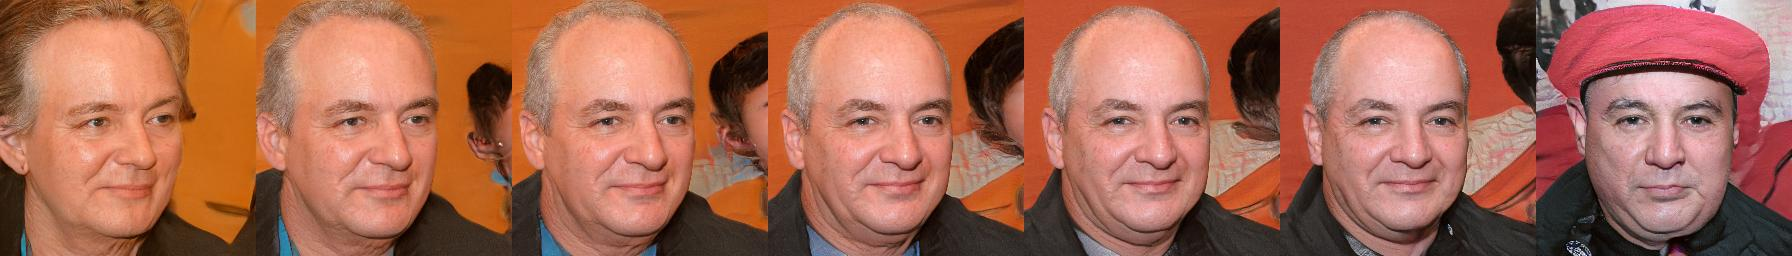

In [42]:
import pandas as pd
import numpy as np
import torch

print("Cargando el vector PCA descubierto en R...")

# 1. Cargamos el vector de R
df_pca = pd.read_csv('/content/direccion_pca3.csv')
# Para que esto no dé error, hay que meter previamente los archivos en la carpeta content

# Lo convertimos a formato NumPy y lo transponemos para que encaje bien (1, 512)
vector_pca = df_pca.values.T

# 2. Generamos una cara base aleatoria para probar
# Usamos la función anterior
w_base = latent_codes[0:2]

# 3. Preparamos una lista vacía para guardar la evolución de la cara
imagenes_evolucion = []

# 4. Definimos las intensidades (alfa)
# Vamos a ir desde un extremo negativo hasta un extremo positivo
# 0.0 representa la cara base sin modificaciones
intensidades = [-4.0, -2.0, -1.0, 0.0, 1.0, 2.0, 5.0]

print("Generando imágenes...")

for alfa in intensidades:
    # Sumamos a la cara base el vector PCA multiplicado por la intensidad
    w_modificado = w_base + (alfa * vector_pca)

    salida = generator.easy_synthesize(w_modificado, latent_space_type='W')
    imagen_final = salida['image'][0]

    # Guardamos la imagen generada en nuestra lista
    imagenes_evolucion.append(imagen_final)

print("Resultados:")

# 5. Visualización
# Convertimos la lista a un array tridimensional para la función
imagenes_array = np.array(imagenes_evolucion)

# Tantas columnas como intensidades hemos probado (7)
imshow(imagenes_array, col=len(intensidades))

***SVM (Etiquetas)***

In [43]:
import pandas as pd
import numpy as np

# 1. Generamos las 1000 caras
numero_de_caras = 1000
print(f"1. Generando {numero_de_caras} vectores W")
vectores_w = sample_codes(generator, numero_de_caras, latent_space_type='W')

# 2. Verificamos los nombres que usa el programa para etiquetar:
nombres_disponibles = ATTRS
print(f"2. Atributos detectados: {nombres_disponibles}")

# Los rasgos que queremos son:
atributos_deseados = ['smile', 'eyeglasses', 'gender']

#3. Creamos la tabla
print("3. Construyendo la tabla de datos...")

# Creamos el DataFrame directamente con los 512 valores de W
columnas_w = [f'w_{i}' for i in range(512)]
df_tfg = pd.DataFrame(vectores_w, columns=columnas_w)

# 4. Hay que pedirle al ordenador que nos etiquete las fotos
for attr in atributos_deseados:
      if attr in ATTRS:
          print(f"   -> Evaluando '{attr}' usando vectores de dirección...")
          # Calculamos la proyección de los códigos latentes sobre el vector de dirección del atributo.
          # Esto proporciona una puntuación que indica cuánto se alinea cada cara con el atributo.
          scores = np.dot(vectores_w, boundaries[attr].T).flatten()
          # Añadimos una columna de puntuaciones a la tabla
          df_tfg[attr] = scores
      else:
          print(f"   El atributo '{attr}' no existe en este modelo.")

# 5. Verificación y resguardo
print("-" * 40)
filas, columnas = df_tfg.shape
print(f"RESUMEN FINAL:")
print(f"- Filas (Caras): {filas} (Debe ser 1000)")
print(f"- Columnas: {len(columnas_w) + len(atributos_deseados)} (512 de W + {len(atributos_deseados)} de atributos)")

if filas == 1000 and columnas == (512 + len(atributos_deseados)):
    nombre_archivo = "datos_supervisados_tfg.csv"
    df_tfg.to_csv(nombre_archivo, index=False)
    print(f"\n El archivo '{nombre_archivo}' se ha generado correctamente.")
else:
    print("\nERROR: La tabla no tiene el tamaño correcto. Revisa los mensajes de arriba.")



1. Generando 1000 vectores W
2. Atributos detectados: ['age', 'eyeglasses', 'gender', 'pose', 'smile']
3. Construyendo la tabla de datos...
   -> Evaluando 'smile' usando vectores de dirección...
   -> Evaluando 'eyeglasses' usando vectores de dirección...
   -> Evaluando 'gender' usando vectores de dirección...
----------------------------------------
RESUMEN FINAL:
- Filas (Caras): 1000 (Debe ser 1000)
- Columnas: 515 (512 de W + 3 de atributos)

 El archivo 'datos_supervisados_tfg.csv' se ha generado correctamente.


SOLO EJECUTAR EL SIGUIENTE CÓDIGO CUANDO SE QUIERAN EXPORTAR LOS DATOS DE LAS CARAS PARA HACER EN R EL SVM


In [44]:
# 6. Para no pararnos a buscarlo, vamos a poner para descargarlo
from google.colab import files
files.download('datos_supervisados_tfg.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ahora, en R, sacamos el vector normal con etiquetas guardado como *datos_supervisados_tfg.csv*:



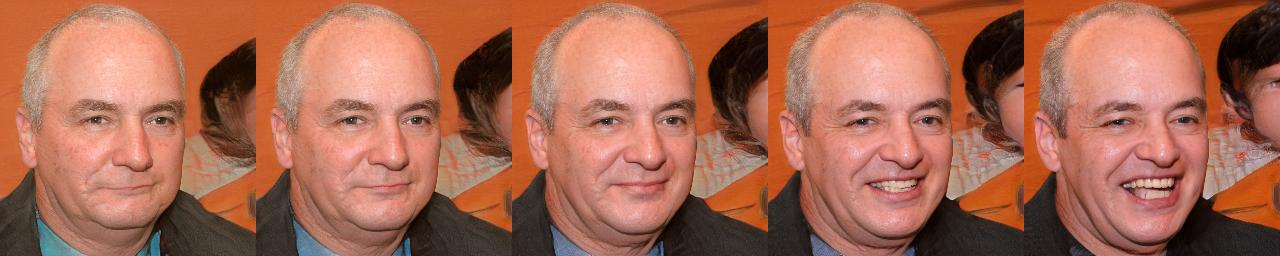

In [45]:
# Cargar la dirección calculada en R mediante SVM
dir_svm = pd.read_csv('/content/direccion_svm_smile.csv').values
#.values para sacar solo los números (para poder usar directamente dir_svm en una cuenta)

# Elegir una cara base:
w_base = latent_codes[0:1]
# Esto lo debemos hacer dependiendo de la cara base que tengamos, puesto que si
# tenemos un señor con gafas y le ponemos como intensidad hasta el número 3, quizás
# el programa podría colapsar y aparecer en la imagen cosas raras como manchas puesto
# que estamos añadiendo cosas que ya están
intensidades = [-3, -1.5, 0, 1.5, 3]
imagenes = []

for alfa in intensidades:
    # Aplicamos la dirección SVM
    w_nuevo = w_base + (alfa * dir_svm)

    # Generamos la imagen
    img = generator.easy_synthesize(w_nuevo, latent_space_type='W')['image'][0]
    imagenes.append(img)

# Mostramos el resultado final
imshow(np.array(imagenes), col=len(intensidades))

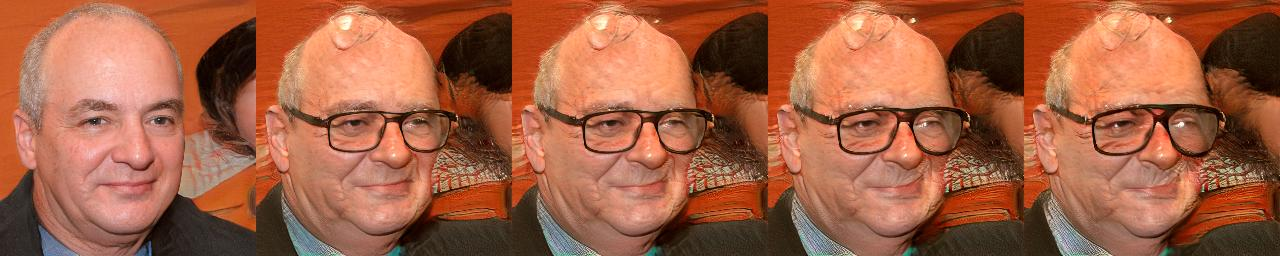

In [46]:
# Cargar la dirección calculada en R mediante SVM
dir_svm = pd.read_csv('/content/direccion_svm_eyeglasses.csv').values

# Elegir una cara base (la número 0, por ejemplo)
w_base = latent_codes[0:2]

# En este caso, como no tiene gafas, solo añadiremos intensidades positivas,
# si probásemos con -3, saldría una cara con manchas, puesto que el programa
# "se raya" y empieza a poner esos colores raros
intensidades = [0, 10, 11, 12, 13] # además, vemos como cuando ponemos intensidad 5
# ya crea algo raro, puesto que "ha llegado a su límite"
imagenes = []

for alfa in intensidades:
    # Aplicamos la dirección SVM
    w_nuevo = w_base + (alfa * dir_svm)

    # Generamos la imagen
    img = generator.easy_synthesize(w_nuevo, latent_space_type='W')['image'][0]
    imagenes.append(img)

# Mostramos el resultado final
imshow(np.array(imagenes), col=len(intensidades))

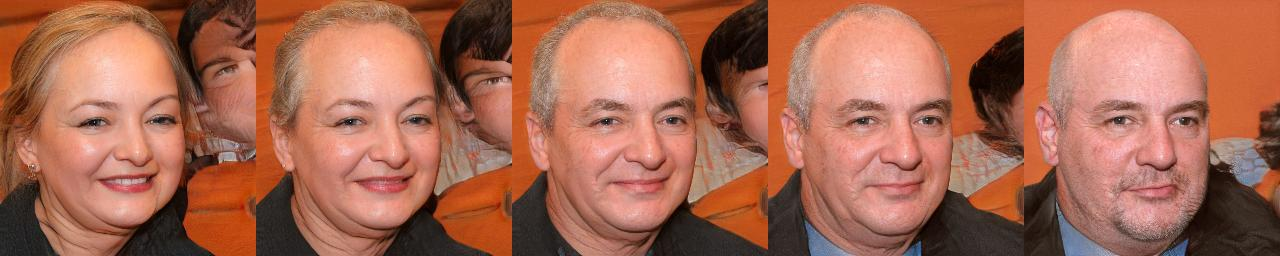

In [47]:
# Cargar la dirección calculada en R mediante SVM
dir_svm = pd.read_csv('/content/direccion_svm_gender.csv').values

# Cogemos la cara base
w_base = latent_codes[0:2]

# Ponemos intensidades lejanas del 0 para ver el cambio brusco de género
intensidades = [-10, -6, -3, 1.5, 10]
imagenes = []

for alfa in intensidades:
    # Aplicamos la dirección SVM
    w_nuevo = w_base + (alfa * dir_svm)

    # Generamos la imagen
    img = generator.easy_synthesize(w_nuevo, latent_space_type='W')['image'][0]
    imagenes.append(img)

# Mostramos el resultado final
imshow(np.array(imagenes), col=len(intensidades))